In [122]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Hate speech dataset

In [125]:
df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Raw/balanced_hate_dataset_18k.csv")
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,18397,3,2,1,0,0,RT @VillageBae: I hate when faggots talk shit ...
1,12358,3,2,0,1,0,Jennifer Lawrence's nudes sooooo trash. Im sti...
2,22556,3,2,1,0,0,This kid looks like a retard when he tries hid...
3,18489,3,2,1,0,0,RT @Woody_AFC: @MANIAC3X @_WhitePonyJr_ lmaooo...
4,17566,3,2,1,0,0,RT @STROCORLEONE @ThoughtsOfRandy @Yummys_Worl...


In [126]:
df.shape

(18000, 7)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          18000 non-null  int64 
 1   count               18000 non-null  int64 
 2   hate_speech         18000 non-null  int64 
 3   offensive_language  18000 non-null  int64 
 4   neither             18000 non-null  int64 
 5   class               18000 non-null  int64 
 6   tweet               18000 non-null  object
dtypes: int64(6), object(1)
memory usage: 984.5+ KB


In [128]:
df.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [129]:
df.isnull().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0


In [130]:
df = df[['tweet', 'class']].copy()


In [131]:
df.rename(columns={
    'tweet': 'text',
    'class': 'label'
}, inplace=True)


In [132]:
#cleaning the text by removing the unncessary things

import re

def clean_text(text):
    text = re.sub(r"http\S+", " ", text)        # remove URLs
    text = re.sub(r"@\w+", " ", text)           # remove mentions
    text = re.sub(r"RT\s+", " ", text)          # remove RT
    text = re.sub(r"\s+", " ", text).strip()    # normalize spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)


In [133]:
# removing empty rows
df = df[df['clean_text'].str.len() > 3]
df.reset_index(drop=True, inplace=True)


In [134]:
#adding ID column
df['id'] = df.index


In [135]:
final_df = df[['id', 'clean_text', 'label']]


In [136]:
final_df.head()

,id,clean_text,label
0,0,: I hate when faggots talk shit on here then b...,0
1,1,Jennifer Lawrence's nudes sooooo trash. Im sti...,0
2,2,This kid looks like a retard when he tries hid...,0
3,3,: lmaoooo what a bunch of fags,0
4,4,all deze hoes got past demons in em... YOLO ni...,0


In [137]:
final_df['label'].value_counts()


,count
label,
1,5999
2,5998
0,5978


In [138]:
final_df.to_csv("hate_clean.csv", index=False)


###EDA

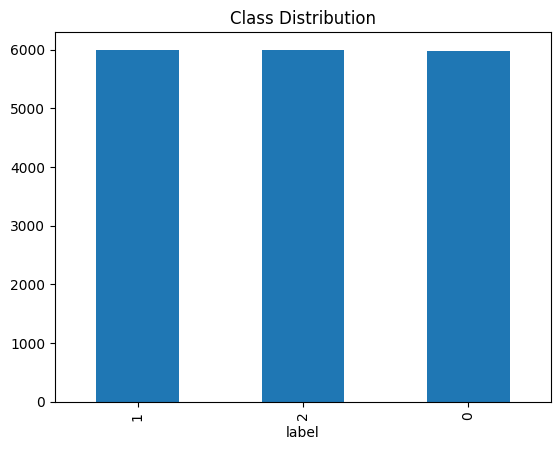

In [139]:
import matplotlib.pyplot as plt

final_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()


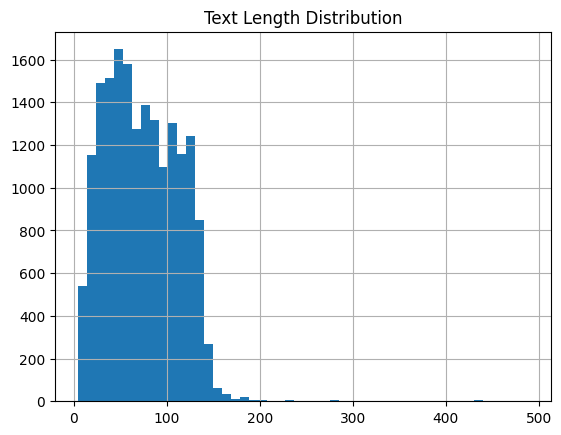

In [140]:
final_df['length'] = final_df['clean_text'].apply(len)

final_df['length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()


In [141]:
final_df[final_df['length'] > 5120]


,id,clean_text,label,length


In [142]:
save_path = "/content/drive/MyDrive/EmiHate/Data/Cleaned/hate_clean.csv"

final_df.to_csv(save_path, index=False)

print("File saved successfully at:", save_path)


File saved successfully at: /content/drive/MyDrive/EmiHate/Data/Cleaned/hate_clean.csv


## Emoji Dataset

In [143]:

emotion_df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Raw/english_emotion_40k.csv")

print(emotion_df.shape)
emotion_df.head()


(40000, 2)


,text,label
0,I am feeling furious about this right now. (0),anger
1,Sometimes I feel extremely annoyed right now. (1),anger
2,Today I feel furious about this today. (2),anger
3,I feel really angry right now. (3),anger
4,Today I feel furious about this right now. (4),anger


In [144]:
print(emotion_df.columns)

Index(['text', 'label'], dtype='object')


In [145]:
emotion_df.columns = emotion_df.columns.str.strip()
print(emotion_df.columns)


Index(['text', 'label'], dtype='object')


In [146]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", " ", str(text))   # remove URLs
    text = re.sub(r"@\w+", " ", text)           # remove mentions
    text = re.sub(r"\s+", " ", text).strip()    # normalize spaces
    return text

emotion_df["clean_text"] = emotion_df["text"].apply(clean_text)


In [147]:
emotion_df = emotion_df[emotion_df["clean_text"].str.len() > 3]
emotion_df.reset_index(drop=True, inplace=True)


In [148]:
emotion_df["id"] = emotion_df.index


In [149]:
final_emotion_df = emotion_df[["id", "clean_text", "label"]]


In [150]:
final_emotion_df.head()
final_emotion_df["label"].value_counts()


,count
label,
anger,8000
fear,8000
hate,8000
neutral,8000
sadness,8000


In [151]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# FIX: overwrite 'label' directly so saved CSV has numeric labels
final_emotion_df = final_emotion_df.copy()  # avoid SettingWithCopyWarning
final_emotion_df["label"] = le.fit_transform(final_emotion_df["label"].astype(str).str.strip())

print(dict(zip(le.classes_, le.transform(le.classes_))))
print('Emotion label range:', final_emotion_df['label'].min(), '-', final_emotion_df['label'].max())


{'anger': np.int64(0), 'fear': np.int64(1), 'hate': np.int64(2), 'neutral': np.int64(3), 'sadness': np.int64(4)}
Emotion label range: 0 - 4


In [152]:
final_emotion_df.head()

,id,clean_text,label
0,0,I am feeling furious about this right now. (0),0
1,1,Sometimes I feel extremely annoyed right now. (1),0
2,2,Today I feel furious about this today. (2),0
3,3,I feel really angry right now. (3),0
4,4,Today I feel furious about this right now. (4),0


In [153]:
save_path = "/content/drive/MyDrive/EmiHate/Data/Cleaned/emotion_clean.csv"

final_emotion_df.to_csv(save_path, index=False)

print("Saved successfully at:", save_path)


Saved successfully at: /content/drive/MyDrive/EmiHate/Data/Cleaned/emotion_clean.csv


### sentiment

In [154]:
import pandas as pd
sent_df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Raw/balanced_sentiment_dataset.csv")

print(sent_df.shape)
sent_df.head()


(13500, 2)


,text,sentiment
0,"@wmdev Every time I succeed with a code, I get...",negative
1,@Catwoman123 Have a good one,negative
2,is tired. 04:30 alarm setting will do that Of...,negative
3,@andrewgoldstein 11 30s way early! anyway nigt...,negative
4,Heading to yale.. Grandmother in car accident,negative


In [155]:
sent_df.columns = sent_df.columns.str.strip()
print(sent_df.columns)


Index(['text', 'sentiment'], dtype='object')


In [156]:
sent_df.rename(columns={
    'text': 'text',
    'sentiment': 'label'
}, inplace=True)


In [157]:
sent_df.head()

,text,label
0,"@wmdev Every time I succeed with a code, I get...",negative
1,@Catwoman123 Have a good one,negative
2,is tired. 04:30 alarm setting will do that Of...,negative
3,@andrewgoldstein 11 30s way early! anyway nigt...,negative
4,Heading to yale.. Grandmother in car accident,negative


In [158]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", " ", str(text))   # remove URLs
    text = re.sub(r"@\w+", " ", text)           # remove mentions
    text = re.sub(r"\s+", " ", text).strip()
    return text

sent_df["clean_text"] = sent_df["text"].apply(clean_text)


In [159]:
sent_df = sent_df[sent_df["clean_text"].str.len() > 3]
sent_df.reset_index(drop=True, inplace=True)


In [160]:
sent_df["id"] = sent_df.index


In [161]:
sent_df.rename(columns={"label": "sentiment_label"}, inplace=True)


In [162]:
final_sent_df = sent_df[["id", "clean_text", "sentiment_label"]]

final_sent_df.head()


,id,clean_text,sentiment_label
0,0,"Every time I succeed with a code, I get ""We're...",negative
1,1,Have a good one,negative
2,2,is tired. 04:30 alarm setting will do that Off...,negative
3,3,11 30s way early! anyway nigth night love you!,negative
4,4,Heading to yale.. Grandmother in car accident,negative


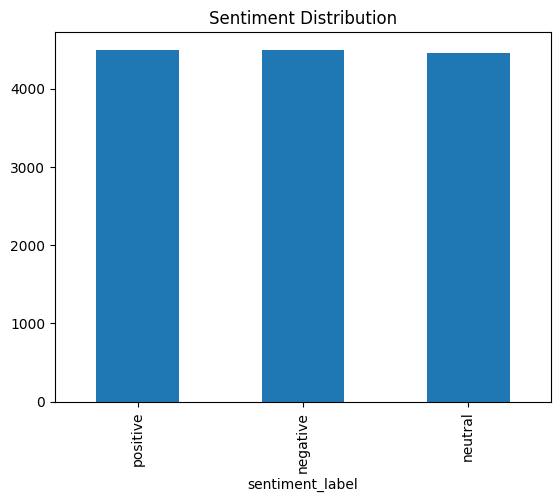

In [163]:
import matplotlib.pyplot as plt

final_sent_df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()


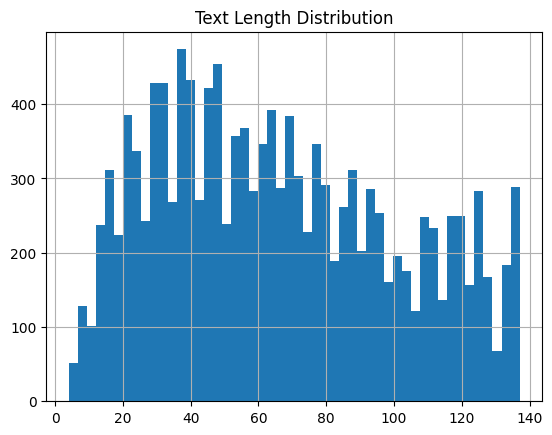

In [164]:
final_sent_df["length"] = final_sent_df["clean_text"].apply(len)

final_sent_df["length"].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()


In [165]:
final_sent_df[final_sent_df["length"] > 512]


,id,clean_text,sentiment_label,length


In [166]:
save_path = "/content/drive/MyDrive/EmiHate/Data/Cleaned/sentiment_clean.csv"

final_sent_df.to_csv(save_path, index=False)

print("Saved successfully at:", save_path)


Saved successfully at: /content/drive/MyDrive/EmiHate/Data/Cleaned/sentiment_clean.csv


# **Training Phase**

In [167]:
!pip install transformers datasets --quiet

In [168]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from torch.optim import AdamW
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [169]:
hate_df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Cleaned/hate_clean.csv")
emotion_df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Cleaned/emotion_clean.csv")
sent_df = pd.read_csv("/content/drive/MyDrive/EmiHate/Data/Cleaned/sentiment_clean.csv")

In [170]:
print(hate_df.head())
print(emotion_df.head())
print(sent_df.head())

   id                                         clean_text  label  length
0   0  : I hate when faggots talk shit on here then b...      0     132
1   1  Jennifer Lawrence's nudes sooooo trash. Im sti...      0      73
2   2  This kid looks like a retard when he tries hid...      0      73
3   3                     : lmaoooo what a bunch of fags      0      30
4   4  all deze hoes got past demons in em... YOLO ni...      0      66
   id                                         clean_text  label
0   0     I am feeling furious about this right now. (0)      0
1   1  Sometimes I feel extremely annoyed right now. (1)      0
2   2         Today I feel furious about this today. (2)      0
3   3                 I feel really angry right now. (3)      0
4   4     Today I feel furious about this right now. (4)      0
   id                                         clean_text sentiment_label  \
0   0  Every time I succeed with a code, I get "We're...        negative   
1   1                           

In [171]:
hate_df["label"] = hate_df["label"].astype(int)

In [172]:
emotion_encoder = LabelEncoder()
# Label column is already numeric (encoded when saved) - just ensure int type
# If it's still strings (old CSV), re-encode it
if emotion_df["label"].dtype == object:
    emotion_df["label"] = emotion_encoder.fit_transform(
        emotion_df["label"].astype(str).str.strip()
    )
else:
    emotion_df["label"] = emotion_df["label"].astype(int)
    # Refit encoder on integer class labels for reference
    emotion_encoder.fit(emotion_df["label"])

print('Emotion labels:', sorted(emotion_df["label"].unique()))
print('Emotion label range:', emotion_df['label'].min(), '-', emotion_df['label'].max())


Emotion labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Emotion label range: 0 - 4


In [173]:
def normalize_sentiment(x):
    x = str(x).strip().lower()
    if x in ["negative", "-1", "neg"]:
        return 0
    elif x in ["neutral", "0", "neu"]:
        return 1
    elif x in ["positive", "1", "pos"]:
        return 2
    else:
        print(f"WARNING: Unknown sentiment label: '{x}' - mapping to 1 (neutral)")
        return 1  # safe fallback instead of crashing

sent_df["label"] = sent_df["sentiment_label"].apply(normalize_sentiment)
print('Sentiment labels:', sorted(sent_df["label"].unique()))
print('Sentiment label range:', sent_df['label'].min(), '-', sent_df['label'].max())


Sentiment labels: [np.int64(0), np.int64(1), np.int64(2)]
Sentiment label range: 0 - 2


In [174]:
hate_df["task"] = 0
emotion_df["task"] = 1
sent_df["task"] = 2

In [175]:
hate_df = hate_df[["clean_text", "label", "task"]]
emotion_df = emotion_df[["clean_text", "label", "task"]]
sent_df = sent_df[["clean_text", "label", "task"]]

In [176]:
full_df = pd.concat([hate_df, emotion_df, sent_df], ignore_index=True)
print(full_df.isna().sum())

clean_text    0
label         0
task          0
dtype: int64


In [177]:
train_df, val_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [178]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
MAX_LEN = 128

In [179]:
train_encodings = tokenizer(
    list(train_df["clean_text"]),
    padding=True,
    truncation=True,
    max_length=MAX_LEN
)

val_encodings = tokenizer(
    list(val_df["clean_text"]),
    padding=True,
    truncation=True,
    max_length=MAX_LEN
)

In [180]:
class MultiTaskDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, df):
        self.encodings = encodings
        self.labels = df["label"].values
        self.tasks = df["task"].values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "label": torch.tensor(self.labels[idx]),
            "task": torch.tensor(self.tasks[idx]),
        }

        return item

In [181]:
num_hate = int(hate_df["label"].max()) + 1
num_emotion = int(emotion_df["label"].max()) + 1
num_sent = int(sent_df["label"].max()) + 1

print(f"num_hate classes: {num_hate}")
print(f"num_emotion classes: {num_emotion}")
print(f"num_sent classes: {num_sent}")

# Validate no label is out of bounds
assert hate_df['label'].min() >= 0 and hate_df['label'].max() < num_hate, 'Hate labels OOB!'
assert emotion_df['label'].min() >= 0 and emotion_df['label'].max() < num_emotion, 'Emotion labels OOB!'
assert sent_df['label'].min() >= 0 and sent_df['label'].max() < num_sent, 'Sent labels OOB!'
print('All label ranges validated OK!')


num_hate classes: 3
num_emotion classes: 5
num_sent classes: 3
All label ranges validated OK!


In [182]:
train_dataset = MultiTaskDataset(train_encodings, train_df)
val_dataset = MultiTaskDataset(val_encodings, val_df)

In [183]:
class MultiTaskRoberta(nn.Module):
    def __init__(self, num_hate, num_emotion, num_sent):
        super().__init__()

        self.encoder = RobertaModel.from_pretrained("roberta-base")
        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        self.hate_head = nn.Linear(hidden, num_hate)
        self.emotion_head = nn.Linear(hidden, num_emotion)
        self.sentiment_head = nn.Linear(hidden, num_sent)

    def mean_pool(self, last_hidden, mask):
        mask = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return (last_hidden * mask).sum(1) / mask.sum(1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pool(outputs.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)

        return (
            self.hate_head(pooled),
            self.emotion_head(pooled),
            self.sentiment_head(pooled)
        )

In [184]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True

In [185]:
from torch.optim import AdamW

# Create the model
model = MultiTaskRoberta(
    num_hate=num_hate,
    num_emotion=num_emotion,
    num_sent=num_sent
)

model = model.to(device)

print("Model loaded on:", device)

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda


In [186]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [187]:
import torch.nn.functional as F

def train_one_epoch(model, loader, optimizer, device):

    model.train()

    total_loss = 0

    for batch in loader:

        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        tasks = batch["task"].to(device)

        optimizer.zero_grad()

        hate_logits, emo_logits, sent_logits = model(ids, mask)

        loss = torch.tensor(0.0, device=device)

        # Hate speech task
        hate_mask = (tasks == 0)
        if hate_mask.any():
            loss = loss + 2.0 * F.cross_entropy(
                hate_logits[hate_mask],
                labels[hate_mask]
            )

        # Emotion task
        emo_mask = (tasks == 1)
        if emo_mask.any():
            loss = loss + F.cross_entropy(
                emo_logits[emo_mask],
                labels[emo_mask]
            )

        # Sentiment task
        sent_mask = (tasks == 2)
        if sent_mask.any():
            loss = loss + F.cross_entropy(
                sent_logits[sent_mask],
                labels[sent_mask]
            )

        if loss.item() == 0:
            continue

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    return avg_loss

In [188]:
def evaluate(model, loader, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in loader:

            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            tasks = batch["task"].to(device)

            hate_logits, emo_logits, sent_logits = model(ids, mask)

            loss = torch.tensor(0.0, device=device)

            hate_mask = (tasks == 0)
            if hate_mask.any():
                loss = loss + F.cross_entropy(
                    hate_logits[hate_mask],
                    labels[hate_mask]
                )

            emo_mask = (tasks == 1)
            if emo_mask.any():
                loss = loss + F.cross_entropy(
                    emo_logits[emo_mask],
                    labels[emo_mask]
                )

            sent_mask = (tasks == 2)
            if sent_mask.any():
                loss = loss + F.cross_entropy(
                    sent_logits[sent_mask],
                    labels[sent_mask]
                )

            total_loss += loss.item()

    return total_loss / len(loader)

In [189]:
EPOCHS = 1
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss = evaluate(
        model,
        val_loader,
        device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print("-"*40)

KeyboardInterrupt: 

In [191]:
# # Hate labels (fixed)
# hate_label_map = {
#     0: "Hate",
#     1: "Offensive",
#     2: "Neutral"
# }

# # Emotion labels (from your LabelEncoder)
# emotion_label_map = {
#     i: label for i, label in enumerate(emotion_encoder.classes_)
# }

# # Sentiment labels (manual mapping we defined earlier)
# sentiment_label_map = {
#     0: "Negative",
#     1: "Neutral",
#     2: "Positive"
# }

# Hate labels (fixed)
hate_label_map = {
    0: "Hate",
    1: "Offensive",
    2: "Neutral"
}

# Emotion labels — hardcoded from LabelEncoder output (alphabetical order)
emotion_label_map = {
    0: "Anger",
    1: "Hate",
    2: "Sadness",
    3: "Fear",
    4: "Neutral"
}

# Sentiment labels
sentiment_label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [192]:
#softmax function

import torch.nn.functional as F

def get_probabilities(logits):
    probs = F.softmax(logits, dim=1)
    return probs.detach().cpu().numpy()[0]

In [193]:
def format_percentage(p):
    return f"{p*100:.2f}%"

In [194]:
# def analyze_text_with_probabilities(text):
#     model.eval()

#     enc = tokenizer(
#         text,
#         return_tensors="pt",
#         padding="max_length",
#         truncation=True,
#         max_length=128
#     )

#     input_ids = enc["input_ids"].to(device)
#     mask = enc["attention_mask"].to(device)

#     with torch.no_grad():
#         hate_logits, emo_logits, sent_logits = model(input_ids, mask)

#     # Convert to probabilities
#     hate_probs = get_probabilities(hate_logits)
#     emo_probs = get_probabilities(emo_logits)
#     sent_probs = get_probabilities(sent_logits)

#     print("\n========== 🔎 ANALYSIS RESULT ==========\n")

#     # ------------------ HATE ------------------
#     print("🛑 Hate Detection:")
#     for i, prob in enumerate(hate_probs):
#         label = hate_label_map[i]
#         print(f"   {label:<10} : {format_percentage(prob)}")

#     hate_pred = hate_probs.argmax()
#     print(f"\n➡ FINAL HATE LABEL: **{hate_label_map[hate_pred]}**")
#     print("-"*45)

#     # ------------------ EMOTION ------------------
#     print("😊 Top Emotions:")

#     top2_idx = emo_probs.argsort()[-2:][::-1]

#     for idx in top2_idx:
#         print(f"   {emotion_label_map[idx]:<15} : {format_percentage(emo_probs[idx])}")

#     print("-"*45)

#     # ------------------ SENTIMENT ------------------
#     sent_pred = sent_probs.argmax()
#     print("💬 Sentiment:")
#     print(f"   {sentiment_label_map[sent_pred]} : {format_percentage(sent_probs[sent_pred])}")

#     print("\n========================================\n")

#     return {
#         "hate": hate_label_map[hate_pred],
#         "emotion_top2": [emotion_label_map[i] for i in top2_idx],
#         "sentiment": sentiment_label_map[sent_pred]
#     }


def analyze_text_with_probabilities(text):
    model.eval()

    enc = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=128
    )

    input_ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        hate_logits, emo_logits, sent_logits = model(input_ids, mask)

    # Convert to probabilities
    hate_probs = get_probabilities(hate_logits)
    emo_probs = get_probabilities(emo_logits)
    sent_probs = get_probabilities(sent_logits)

    print("\n========== 🔎 ANALYSIS RESULT ==========\n")

    # ------------------ HATE ------------------
    print("🛑 Hate Detection:")
    for i, prob in enumerate(hate_probs):
        label = hate_label_map[i]
        print(f"   {label:<10} : {format_percentage(prob)}")

    hate_pred = hate_probs.argmax()
    print(f"\n➡ FINAL HATE LABEL: **{hate_label_map[hate_pred]}**")
    print("-"*45)

    # ------------------ EMOTION ------------------
    print("😊 Top Emotions:")
    top2_idx = emo_probs.argsort()[-2:][::-1]

    for idx in top2_idx:
        label = emotion_label_map.get(int(idx), f"Emotion_{idx}")  # safe decode
        print(f"   {label:<15} : {format_percentage(emo_probs[idx])}")

    print("-"*45)

    # ------------------ SENTIMENT ------------------
    sent_pred = sent_probs.argmax()
    print("💬 Sentiment:")
    print(f"   {sentiment_label_map[sent_pred]} : {format_percentage(sent_probs[sent_pred])}")

    print("\n========================================\n")

    return {
        "hate": hate_label_map[hate_pred],
        "emotion_top2": [emotion_label_map.get(int(i), f"Emotion_{i}") for i in top2_idx],
        "sentiment": sentiment_label_map[sent_pred]
    }


In [195]:
analyze_text_with_probabilities(
    "i was broken up and get frustated with anger of issues in a moment 😡😡😡.."
)


========== 🔎 ANALYSIS RESULT ==========

🛑 Hate Detection:
   Hate       : 15.78%
   Offensive  : 59.62%
   Neutral    : 24.60%

➡ FINAL HATE LABEL: **Offensive**
---------------------------------------------
😊 Top Emotions:
   Anger           : 34.22%
   Sadness         : 22.68%
---------------------------------------------
💬 Sentiment:
   Negative : 63.92%




{'hate': 'Offensive',
 'emotion_top2': ['Anger', 'Sadness'],
 'sentiment': 'Negative'}

#model Saving

In [196]:
save_path = "/content/drive/MyDrive/EmiHate/Models/Roberta_engl"

# Save encoder + tokenizer
model.encoder.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save full model weights (heads included)
import torch
torch.save(model.state_dict(), save_path + "/model_heads.pt")

print("✅ English model saved locally")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ English model saved locally
